In [4]:
import matplotlib.pyplot as plt
import numpy as np
from oitg.results import load_result
from scipy.optimize import curve_fit
import graph_style as gs

gs.set_graph_style(1.0)


def load_data(rid, day):
    f = load_result(rid=rid, day=day, experiment="fastgates")
    print(f["datasets"].keys())
    freqs = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])
    p = np.zeros((len(freqs), 5))
    p_err = np.zeros((len(freqs), 5))
    for ind in range(5):
        p[:, ind] = f["datasets"][
            f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_{ind}"
        ]
        p_err[:, ind] = f["datasets"][
            f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_err_{ind}"
        ]

    return freqs, p, p_err


# rid = 40421
# date = "2025-07-17"
# f, p, p_err = load_data(rid, data)

date = "2025-07-26"
# rid = 43767
rid = 43775
x_raw, p, p_err = load_data(rid, date)

dict_keys(['ndscan.rid_43775.analysis_results', 'ndscan.rid_43775.annotations', 'ndscan.rid_43775.axes', 'ndscan.rid_43775.channels', 'ndscan.rid_43775.completed', 'ndscan.rid_43775.fragment_fqn', 'ndscan.rid_43775.ndscan_schema_revision', 'ndscan.rid_43775.online_analyses', 'ndscan.rid_43775.points.axis_0', 'ndscan.rid_43775.points.channel_crystal_check_readout_counts', 'ndscan.rid_43775.points.channel_crystal_check_readout_is_brights', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_0', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_1', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_2', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_3', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_4', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_err', 'ndscan.rid_43775.points.channel_measurement_camera_readout_p_err_0', 'ndscan.rid_43775.points.c

Mean waist: 1.46 um


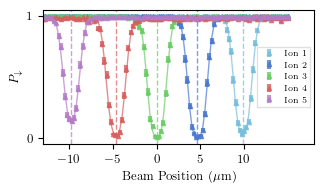

In [27]:
def fit_func(x, waist, amp, offset):
    return 1 - np.sin(amp * np.exp(-((x - offset) ** 2) / (waist**2))) ** 2


# x = get_position_from_freqs((f,) * 2)[1]

popt, pcov = curve_fit(
    fit_func,
    x_raw,
    p[:, 2],
    p0=[2, 1.0, 1],
)
x = x_raw - popt[2]

sort_mask = np.argsort(x)
clip_mask = np.abs(x[sort_mask]) < 1e10
x = x[sort_mask][clip_mask]

waists = np.zeros(5)
fig_width = gs.get_fig_width()*0.6
fig_height = fig_width * 0.5
plt.figure(figsize=(fig_width, fig_height))
for ind in range(5):
    y = p[:, ind][sort_mask][clip_mask]
    y_err = p_err[:, ind][sort_mask][clip_mask]

    popt, pcov = curve_fit(
        fit_func, x, y, p0=[2, 1.0, 1.0], sigma=y_err, absolute_sigma=True
    )
    waists[ind] = np.abs(popt[0])

    color = gs.get_color(ind-1)
    plt.errorbar(
        x,
        y,
        yerr=y_err,
        label=f"Ion {ind + 1}",
        fmt="^",
        alpha=0.8,
        color=color,
        # ms=5,
        elinewidth=3,
    )
    plt.plot(
        x,
        fit_func(x, *popt),
        color=color,
        linestyle="-",
        alpha=0.7,
    )
    plt.axvline(popt[2], color=color,  alpha=0.7)

print(f"Mean waist: {np.mean(waists):.2f} um")
plt.ylim(-0.05, 1.05)
plt.yticks([0,1])
plt.xlim(np.min(x)+2, np.max(x) + 3)
plt.xticks(np.arange(-10, 11, 5))
plt.legend(ncols=1, loc="right")
plt.xlabel("Beam Position ($\\mu$m)")
plt.ylabel("$P_\\downarrow$")
plt.grid(None)
f_name = "..\\..\\pdf_figure\\ch4\\sa_scan.pdf"
plt.savefig(f_name, bbox_inches="tight", dpi=300)

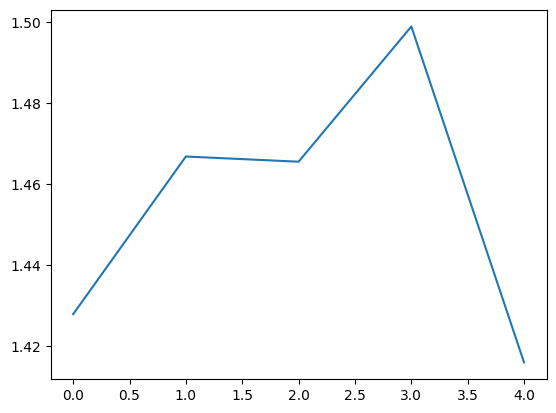

In [34]:
plt.plot(waists)

In [40]:
t_pi = np.array([520,300,1.775,62.8,94.5])
t_pi_err = np.array([80, 10, 0.003, 0.1, 0.2])

def tpi_to_rabi(t_pi, t_pi_err):
    f = np.pi/(2*np.pi*t_pi)*1000 # kHz
    f_err = f * (t_pi_err / t_pi)
    return f, f_err

f, f_err = tpi_to_rabi(t_pi, t_pi_err)
print(f, f_err)
w_norm = f**2 / np.max(f**2)
w_err_norm = w_norm * (2 * f_err / f)
# remove 3rd entry
w_norm = np.delete(w_norm, 2)
w_err_norm = np.delete(w_err_norm, 2)
print(w_norm, w_err_norm)
r_mean = np.mean(w_norm)*10000
r_std = np.std(w_norm)*10000
print(f"Mean intensity crosstalk: {r_mean} +- {r_std}")



[  0.96153846   1.66666667 281.69014085   7.96178344   5.29100529] [0.14792899 0.05555556 0.47609601 0.012678   0.01119789]
[1.16517197e-05 3.50069444e-05 7.98872419e-04 3.52803673e-04] [3.58514452e-06 2.33379630e-06 2.54417968e-06 1.49334888e-06]
Mean intensity crosstalk: 2.9958368894696883 +- 3.182087660134882
